# Standard Scaler with PyTorch

Two features walk into a model.

**Age** whispers: *"I'm 35."*

**Salary** kicks the door down: *"I MAKE ONE HUNDRED AND FIFTY THOUSAND."*

The model, being a little rude, only listens to whoever shouts louder.

Today we teach them indoor voices with **Standard Scaler**:

$$
z = \frac{x - \mu}{\sigma}
$$

After this, both features speak the same language: *how many standard deviations from the mean.*

## 1. Setup and a first look

We use the **Social Network Ads** dataset. Each row is a person. The question is: did they buy (`Purchased`) after seeing an ad?

For scaling we only keep **Age** and **EstimatedSalary**.

- `User ID` is a name tag. Drop it. Scaling a student ID does not make them taller.
- `Gender` is a category, not a number on a ruler. Leave it out of this lesson.

In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

%matplotlib inline
torch.manual_seed(42)

path = kagglehub.dataset_download("rakeshrau/social-network-ads")
print("Path to dataset files: ", path)

100%|██████████| 3.27k/3.27k [00:00<00:00, 7.06MB/s]

Extracting files...
Path to dataset files:  /root/.cache/kagglehub/datasets/rakeshrau/social-network-ads/versions/1


In [2]:
csv_path = next(Path(path).rglob("*.csv"))
print("CSV:", csv_path)

df = pd.read_csv(csv_path)
df.head()

CSV: /root/.cache/kagglehub/datasets/rakeshrau/social-network-ads/versions/1/Social_Network_Ads.csv


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Age range:    ", int(df["Age"].min()), "→", int(df["Age"].max()))
print("Salary range: ", int(df["EstimatedSalary"].min()), "→", int(df["EstimatedSalary"].max()))
print()
ratio = df["EstimatedSalary"].max() / df["Age"].max()
print(f"At the top end, salary is about {ratio:.0f}× bigger than age.")
print("That's not a fair debate. That's a megaphone vs a whisper.")

Shape: (400, 5)

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

Age range:     18 → 60
Salary range:  15000 → 150000

At the top end, salary is about 2500× bigger than age.
That's not a fair debate. That's a megaphone vs a whisper.


## 2. Why scale?

Imagine averaging **exam marks (0–100)** with **monthly salary (tens of thousands)**. Salary eats the average. The exam might as well not exist.

A model that computes `weight * Age + weight * Salary` has the same problem. Huge numbers get huge votes — even if Age is the smarter clue.

Look at the raw scatter. Salary stretches the plot like pizza dough.

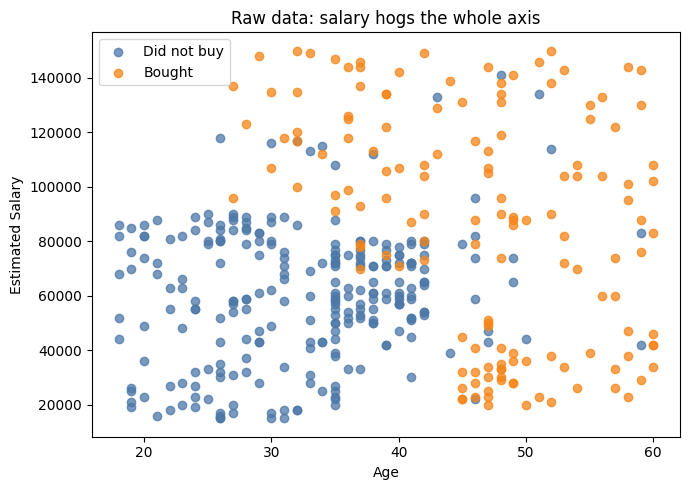

In [5]:
bought = df["Purchased"] == 1

plt.figure(figsize=(7, 5))
plt.scatter(
    df.loc[~bought, "Age"], df.loc[~bought, "EstimatedSalary"],
    c="#4C78A8", alpha=0.75, label="Did not buy",
)
plt.scatter(
    df.loc[bought, "Age"], df.loc[bought, "EstimatedSalary"],
    c="#F58518", alpha=0.75, label="Bought",
)
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Raw data: salary hogs the whole axis")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Standard Scaler in PyTorch

PyTorch has no built-in `StandardScaler`. The whole trick is five lines of math:

1. Find the **mean** of each column (the typical value).
2. Find the **standard deviation** of each column (how spread out it is).
3. Subtract the mean, divide by the std.

We use `unbiased=False` so we divide by **n** (population std). That matches sklearn's `StandardScaler`.

In human words: *how weird is this person, in standard-person units?*

In [6]:
features_cols = ["Age", "EstimatedSalary"]
X_all = torch.tensor(df[features_cols].values, dtype = torch.float32)
y_all = torch.tensor(df["Purchased"].values, dtype = torch.float32)
bought_t = y_all.bool()

print("X Shape: ", tuple(X_all.shape))
print("First 5 rows (raw): ")
print(X_all[:5])

X Shape:  (400, 2)
First 5 rows (raw): 
tensor([[1.9000e+01, 1.9000e+04],
        [3.5000e+01, 2.0000e+04],
        [2.6000e+01, 4.3000e+04],
        [2.7000e+01, 5.7000e+04],
        [1.9000e+01, 7.6000e+04]])


In [8]:
class TorchStandardScaler:
    """A tiny sklearn-style scaler, but in PyTorch."""

    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = X.mean(dim=0)
        self.std_ = X.std(dim=0, unbiased=False)
        self.std_ = torch.where(self.std_ == 0, torch.ones_like(self.std_), self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# Demo on ALL rows first, so we can see the magic.
# The honest way is train-only. That's the next section.
demo_scaler = TorchStandardScaler()
X_demo = demo_scaler.fit_transform(X_all)

print("Learned mean:", [round(v, 2) for v in demo_scaler.mean_.tolist()])
print("Learned std: ", [round(v, 2) for v in demo_scaler.std_.tolist()])
print()
print("First 5 rows (scaled):")
print(X_demo[:5])

Learned mean: [37.65, 69742.5]
Learned std:  [10.47, 34054.31]

First 5 rows (scaled):
tensor([[-1.7818, -1.4900],
        [-0.2536, -1.4607],
        [-1.1132, -0.7853],
        [-1.0177, -0.3742],
        [-1.7818,  0.1838]])


In [9]:
print("After scaling — mean of each column (want ~0):", X_demo.mean(dim=0).tolist())
print("After scaling — std  of each column (want ~1):", X_demo.std(dim=0, unbiased=False).tolist())
print()
print("Age and salary now speak the same language. Peace treaty signed.")

After scaling — mean of each column (want ~0): [1.1682510603350238e-07, -4.76837147544984e-09]
After scaling — std  of each column (want ~1): [1.0, 1.0]

Age and salary now speak the same language. Peace treaty signed.


## 4. Before vs after (the projector slide)

Left: a stretched sausage. Right: a blob you can actually look at.

Blue = did not buy. Orange = bought.

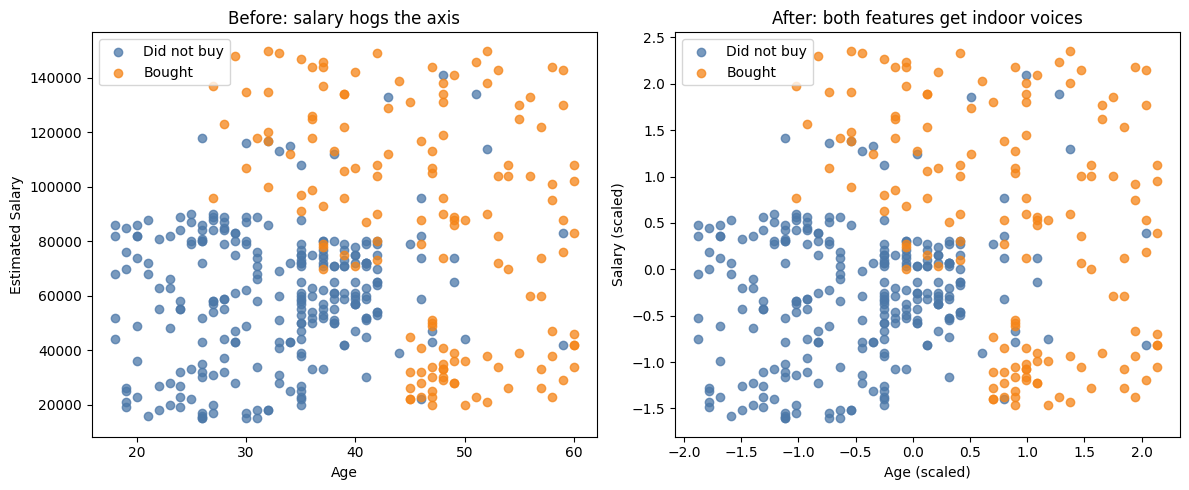

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    X_all[~bought_t, 0], X_all[~bought_t, 1],
    c="#4C78A8", alpha=0.75, label="Did not buy",
)
axes[0].scatter(
    X_all[bought_t, 0], X_all[bought_t, 1],
    c="#F58518", alpha=0.75, label="Bought",
)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Estimated Salary")
axes[0].set_title("Before: salary hogs the axis")
axes[0].legend()

axes[1].scatter(
    X_demo[~bought_t, 0], X_demo[~bought_t, 1],
    c="#4C78A8", alpha=0.75, label="Did not buy",
)
axes[1].scatter(
    X_demo[bought_t, 0], X_demo[bought_t, 1],
    c="#F58518", alpha=0.75, label="Bought",
)
axes[1].set_xlabel("Age (scaled)")
axes[1].set_ylabel("Salary (scaled)")
axes[1].set_title("After: both features get indoor voices")
axes[1].legend()

plt.tight_layout()
plt.show()

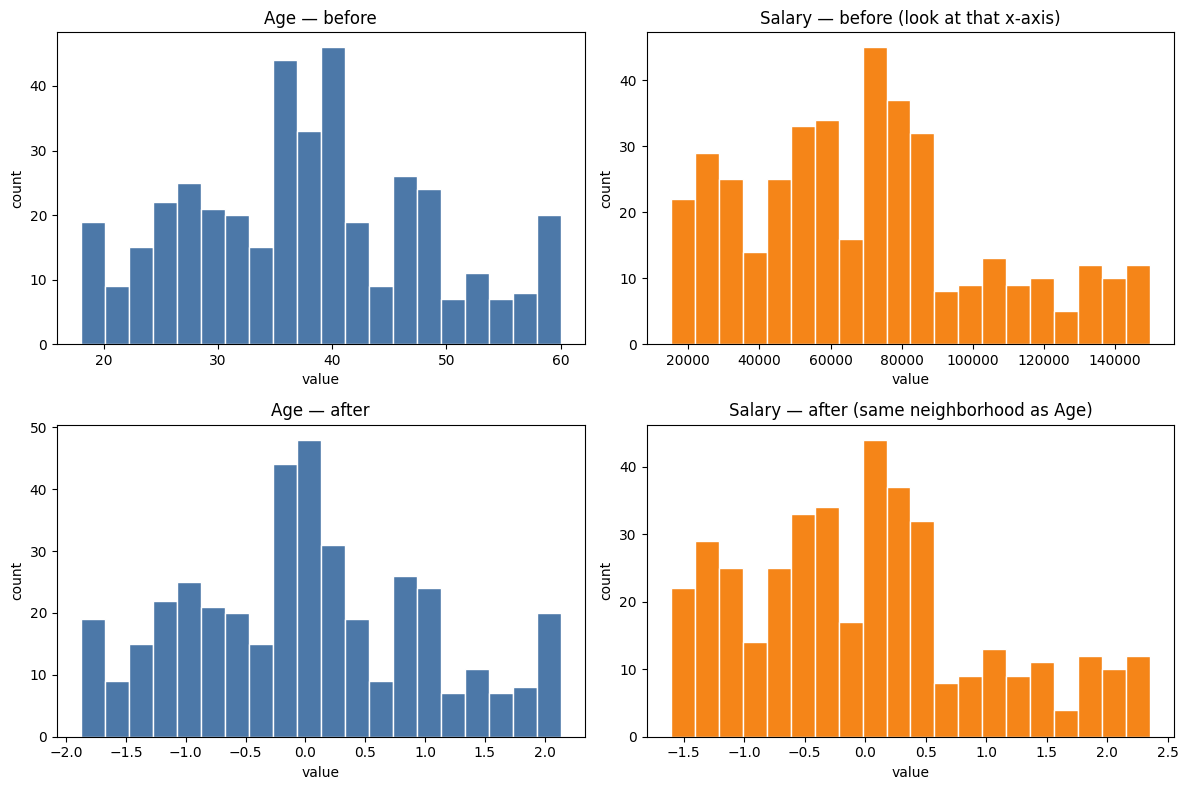

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(X_all[:, 0].numpy(), bins=20, color="#4C78A8", edgecolor="white")
axes[0, 0].set_title("Age — before")

axes[0, 1].hist(X_all[:, 1].numpy(), bins=20, color="#F58518", edgecolor="white")
axes[0, 1].set_title("Salary — before (look at that x-axis)")

axes[1, 0].hist(X_demo[:, 0].numpy(), bins=20, color="#4C78A8", edgecolor="white")
axes[1, 0].set_title("Age — after")

axes[1, 1].hist(X_demo[:, 1].numpy(), bins=20, color="#F58518", edgecolor="white")
axes[1, 1].set_title("Salary — after (same neighborhood as Age)")

for ax in axes.ravel():
    ax.set_xlabel("value")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

## 5. Fit on train only (don't cheat)

If you compute mean and std on **all 400 people**, the test set has already leaked into the homework.

That's like peeking at the exam, then acting surprised you scored well.

**Rule:** `fit` on train. `transform` train **and** test with those same numbers.

In [12]:
n = X_all.shape[0]
perm = torch.randperm(n)
train_size = int(0.8 * n)

train_idx = perm[:train_size]
test_idx = perm[train_size:]

X_train_raw = X_all[train_idx]
X_test_raw = X_all[test_idx]
y_train = y_all[train_idx]
y_test = y_all[test_idx]

scaler = TorchStandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)  # same mean/std as train. No peeking.

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])
print("Train mean used:", [round(v, 2) for v in scaler.mean_.tolist()])
print("Train std used: ", [round(v, 2) for v in scaler.std_.tolist()])
print("Test mean after transform (not forced to 0):", X_test.mean(dim=0).tolist())
print()
print("Test mean is close to 0, not exactly 0. That's honest.")
print("The test people were not in the class photo.")

Train size: 320 | Test size: 80
Train mean used: [37.95, 68640.62]
Train std used:  [10.56, 34375.67]
Test mean after transform (not forced to 0): [-0.13819515705108643, 0.160269632935524]

Test mean is close to 0, not exactly 0. That's honest.
The test people were not in the class photo.


## 6. Same tiny model, two worlds

One logistic regression. Two feature versions. Same learning rate, same epochs.

`nn.Linear(2, 1)` plus `BCEWithLogitsLoss` is just:

`score = w_age * Age + w_salary * Salary + bias`

If salary is still yelling, one gradient step can overshoot. Loss goes to infinity, and we all pretend we meant to do that.

In [13]:
def train_logreg(X_tr, y_tr, X_te, y_te, epochs=200, lr=0.1, label=""):
    torch.manual_seed(42)
    model = nn.Linear(2, 1)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    y_tr = y_tr.view(-1, 1)
    y_te = y_te.view(-1, 1)
    exploded = False
    last_loss = None

    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(X_tr), y_tr)
        last_loss = loss.item()
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"{label} epoch {epoch}: loss exploded. Salary brought a wrecking ball.")
            exploded = True
            break
        loss.backward()
        opt.step()
        if epoch in (1, 50, 100, epochs):
            print(f"{label} epoch {epoch:3d}  loss={loss.item():.4f}")

    def accuracy(X, y):
        if exploded:
            return float("nan")
        with torch.no_grad():
            preds = (torch.sigmoid(model(X)) >= 0.5).float()
            return (preds == y).float().mean().item()

    train_acc = accuracy(X_tr, y_tr)
    test_acc = accuracy(X_te, y_te)
    weights = model.weight.detach().flatten().tolist()
    bias = model.bias.detach().item()

    print(f"{label} final loss={last_loss}")
    print(f"{label} train acc={train_acc:.3f}  test acc={test_acc:.3f}")
    print(f"{label} weights  Age={weights[0]:.4f}  Salary={weights[1]:.4f}  bias={bias:.4f}")
    return model

In [14]:
print("=== Unscaled (indoor voice? never heard of it) ===")
model_raw = train_logreg(X_train_raw, y_train, X_test_raw, y_test, label="unscaled")

=== Unscaled (indoor voice? never heard of it) ===
unscaled epoch   1  loss=22179.6406
unscaled epoch  50  loss=9370726.0000
unscaled epoch 100  loss=101298928.0000
unscaled epoch 200  loss=107327976.0000
unscaled final loss=107327976.0
unscaled train acc=0.634  test acc=0.675
unscaled weights  Age=0.8938  Salary=-390.0380  bias=-1.8532


In [15]:
print("=== Scaled (both features behaving) ===")
model_scaled = train_logreg(X_train, y_train, X_test, y_test, label="scaled  ")

=== Scaled (both features behaving) ===
scaled   epoch   1  loss=0.4946
scaled   epoch  50  loss=0.3998
scaled   epoch 100  loss=0.3714
scaled   epoch 200  loss=0.3524
scaled   final loss=0.35237306356430054
scaled   train acc=0.859  test acc=0.800
scaled   weights  Age=1.8203  Salary=0.9132  bias=-0.8142


What to point at in class:

- **Unscaled** often explodes, or the salary weight stays tiny because the numbers are huge.
- **Scaled** trains like a normal person. Loss goes down. Accuracy goes up.
- Same model. Same learning rate. The only change was indoor voices.